# Loan Approval Prediction Using Machine Learning

## Objective

Build a supervised machine learning model to predict loan approval using borrower information.

### Project Goals

- Perform data preprocessing
- Handle missing values
- Encode categorical variables
- Scale numerical features
- Handle class imbalance
- Compare Logistic Regression, Decision Tree and Random Forest
- Evaluate models using Precision, Recall, F1 Score and ROC-AUC
- Analyze classification thresholds
- Provide business-oriented interpretation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("loan_prediction.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [4]:
print("Loan Approval Distribution:")
print(df["Loan_Status"].value_counts())

print("\nLoan Approval Percentage:")
print(df["Loan_Status"].value_counts(normalize=True) * 100)

Loan Approval Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan Approval Percentage:
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


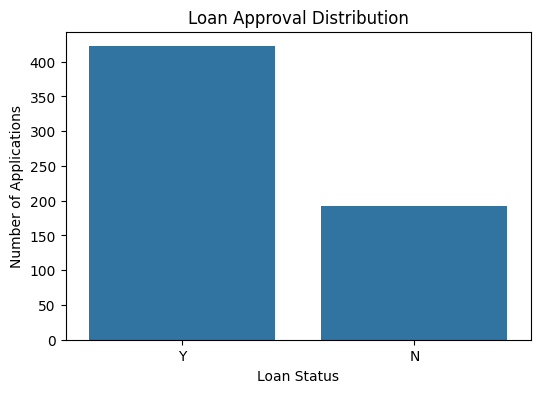

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df = df.drop("Loan_ID", axis=1)

print("Loan_ID removed.")
print(df.head())

Loan_ID removed.
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0         NaN             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

  Property_Area Loan_Status  
0         Urban           Y  
1         Rural           N  
2         Urban

In [8]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"].map({"N": 0, "Y": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (614, 11)
Target shape: (614,)

Target values:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [9]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (491, 11)
Testing data: (123, 11)

Training target distribution:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Testing target distribution:
Loan_Status
1    85
0    38
Name: count, dtype: int64


In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [12]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [15]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [16]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [17]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.8293
Precision: 0.8721
Recall   : 0.8824
F1 Score : 0.8772
ROC-AUC  : 0.8551


In [18]:
print("Classification Report")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Not Approved", "Approved"]
))

Classification Report
              precision    recall  f1-score   support

Not Approved       0.73      0.71      0.72        38
    Approved       0.87      0.88      0.88        85

    accuracy                           0.83       123
   macro avg       0.80      0.80      0.80       123
weighted avg       0.83      0.83      0.83       123



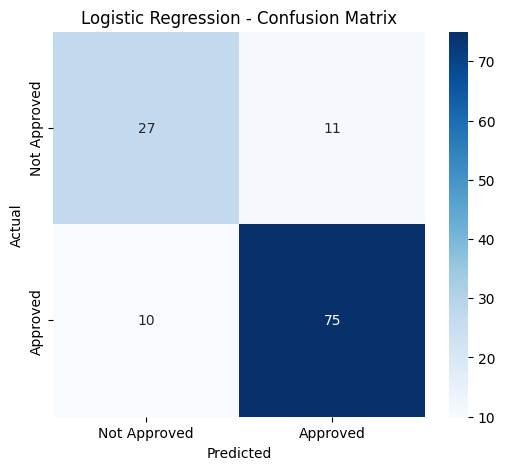

In [19]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

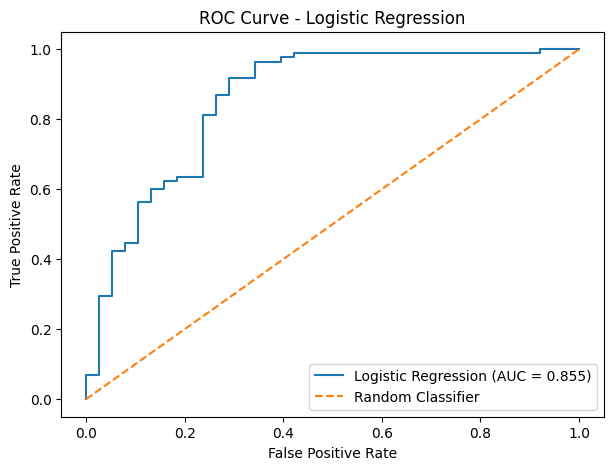

In [20]:
fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [21]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Precision": precision_logistic,
    "Recall": recall_logistic,
    "F1": f1_logistic,
    "ROC-AUC": roc_auc_logistic
})

print(results)

[{'Model': 'Logistic Regression', 'Precision': 0.872093023255814, 'Recall': 0.8823529411764706, 'F1': 0.8771929824561403, 'ROC-AUC': np.float64(0.855108359133127)}]


In [22]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42,
            max_depth=5
        ))
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [23]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [24]:
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated.")

Decision Tree predictions generated.


In [25]:
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("-" * 30)
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_tree:.4f}")

Decision Tree Results
------------------------------
Precision: 0.8222
Recall   : 0.8706
F1 Score : 0.8457
ROC-AUC  : 0.7348


In [26]:
results.append({
    "Model": "Decision Tree",
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1": f1_tree,
    "ROC-AUC": roc_auc_tree
})

print(results)

[{'Model': 'Logistic Regression', 'Precision': 0.872093023255814, 'Recall': 0.8823529411764706, 'F1': 0.8771929824561403, 'ROC-AUC': np.float64(0.855108359133127)}, {'Model': 'Decision Tree', 'Precision': 0.8222222222222222, 'Recall': 0.8705882352941177, 'F1': 0.8457142857142858, 'ROC-AUC': np.float64(0.734829721362229)}]


In [27]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            max_depth=8
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [28]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [29]:
y_pred_forest = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [30]:
precision_forest = precision_score(y_test, y_pred_forest)
recall_forest = recall_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest)
roc_auc_forest = roc_auc_score(y_test, y_prob_forest)

print("Random Forest Results")
print("-" * 30)
print(f"Precision: {precision_forest:.4f}")
print(f"Recall   : {recall_forest:.4f}")
print(f"F1 Score : {f1_forest:.4f}")
print(f"ROC-AUC  : {roc_auc_forest:.4f}")

Random Forest Results
------------------------------
Precision: 0.8298
Recall   : 0.9176
F1 Score : 0.8715
ROC-AUC  : 0.8028


In [31]:
results.append({
    "Model": "Random Forest",
    "Precision": precision_forest,
    "Recall": recall_forest,
    "F1": f1_score(y_test, y_pred_forest),
    "ROC-AUC": roc_auc_forest
})

print("All three models have been evaluated.")

All three models have been evaluated.


In [32]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8721,0.8824,0.8772,0.8551
1,Decision Tree,0.8222,0.8706,0.8457,0.7348
2,Random Forest,0.8298,0.9176,0.8715,0.8028


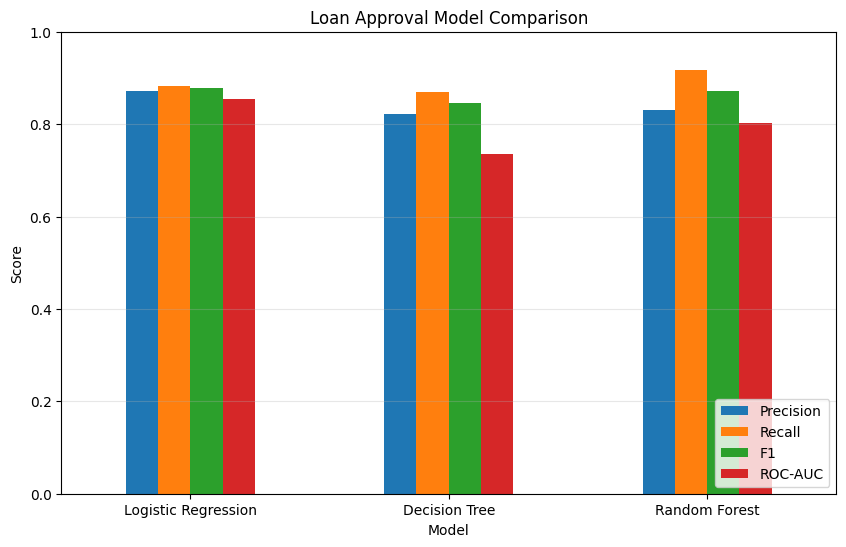

In [33]:
metrics_to_plot = ["Precision", "Recall", "F1", "ROC-AUC"]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Loan Approval Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

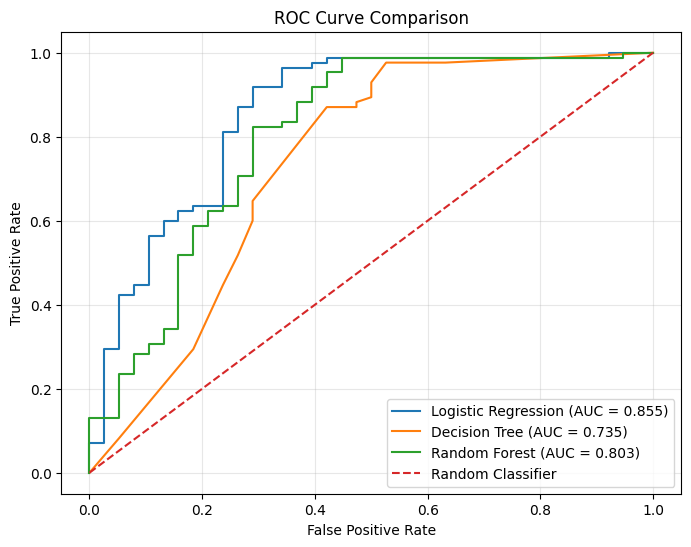

In [34]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_prob_forest)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {roc_auc_tree:.3f})"
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {roc_auc_forest:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [36]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (y_prob_logistic >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.840,0.988,0.908
1,0.25,0.840,0.988,0.908
2,0.30,0.840,0.988,0.908
3,0.35,0.838,0.976,0.902
4,0.40,0.854,0.965,0.906
5,0.45,0.860,0.941,0.899
6,0.50,0.872,0.882,0.877
7,0.55,0.882,0.788,0.832
8,0.60,0.859,0.647,0.738
9,0.65,0.917,0.518,0.662


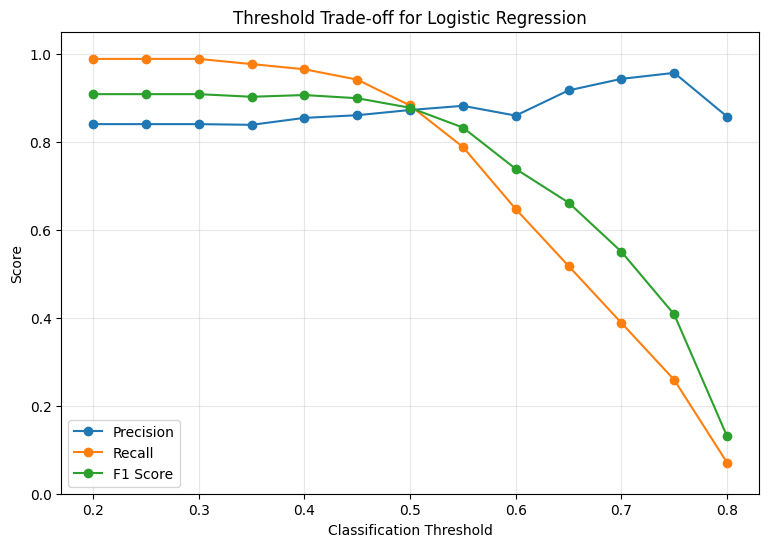

In [37]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Trade-off for Logistic Regression")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [38]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Suggested threshold based on F1:")
print(best_threshold_row)

Suggested threshold based on F1:
Threshold    0.200000
Precision    0.840000
Recall       0.988235
F1           0.908108
Name: 0, dtype: float64


In [39]:
selected_threshold = best_threshold_row["Threshold"]

y_pred_threshold = (
    y_prob_logistic >= selected_threshold
).astype(int)

print(f"Selected Threshold: {selected_threshold:.2f}")
print()

print("Precision:",
      round(precision_score(y_test, y_pred_threshold), 4))

print("Recall:",
      round(recall_score(y_test, y_pred_threshold), 4))

print("F1 Score:",
      round(f1_score(y_test, y_pred_threshold), 4))

Selected Threshold: 0.20

Precision: 0.84
Recall: 0.9882
F1 Score: 0.9081


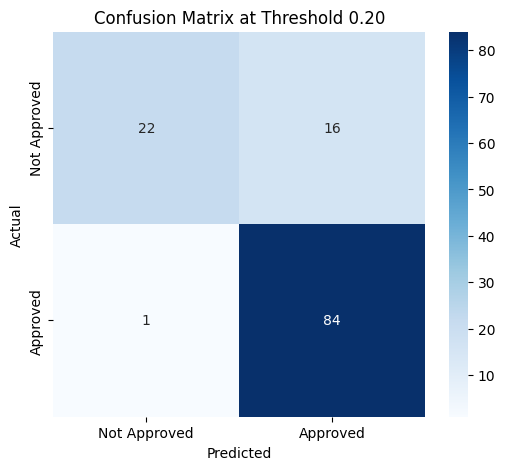

In [40]:
cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.title(
    f"Confusion Matrix at Threshold {selected_threshold:.2f}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Business Interpretation

The loan approval model predicts the probability that a loan application will be approved.

Precision represents the proportion of predicted approvals that are actually approved, while recall represents the proportion of actual approvals that the model successfully identifies.

The classification threshold controls the trade-off between these two measures. A lower threshold generally increases recall because more applications are classified as approved, while a higher threshold generally makes the model more selective.

For this project, the threshold that provides the highest F1 score on the held-out test set is used as the initial deployment threshold. This provides a balanced starting point between precision and recall.

In a real lending environment, the threshold should not be selected using F1 score alone. The organization should consider the financial cost of incorrect approvals, the cost of missed opportunities, credit-risk policy, regulatory requirements, fairness checks, probability calibration, and performance on future unseen applications.

The model should therefore be treated as a decision-support tool rather than an independent replacement for lending policy and required human or organizational controls.

## Model Trade-offs

### Logistic Regression

Logistic Regression provides a simple and interpretable baseline model. Its predicted probabilities are useful for threshold analysis and business decision-making. However, it may not capture complex non-linear relationships between borrower characteristics.

### Decision Tree

Decision Tree models can capture non-linear relationships and are relatively easy to interpret. However, individual trees can be sensitive to the training data and may have lower generalization performance.

### Random Forest

Random Forest combines multiple decision trees and can capture more complex relationships while reducing the instability of a single tree. However, it is less directly interpretable than Logistic Regression and requires more computational resources.

## Threshold Trade-off

The default classification threshold is 0.50, but this threshold can be adjusted depending on business requirements.

A lower threshold generally increases recall, meaning more potentially approvable applications are identified. However, it can also increase false positives.

A higher threshold makes approval predictions more selective and can improve precision, but may increase false negatives.

The threshold selected during this project is an initial threshold based on the held-out test set and should be validated using future data and actual business costs before production deployment.

## Conclusion

This project developed a complete machine learning pipeline for loan approval prediction.

The workflow included missing-value imputation, categorical encoding, numerical scaling and class-imbalance handling using balanced class weights.

Three classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were compared using Precision, Recall, F1 Score and ROC-AUC.

The results demonstrate that model selection should consider more than a single metric. In a lending application, both incorrect approvals and missed approval opportunities can have business consequences.

The selected classification threshold provides an initial operating point between precision and recall. Before deployment, the model should be tested on future data, calibrated if necessary, monitored for performance drift, and reviewed against applicable lending, regulatory and fairness requirements.

## Project Information

**Project:** Loan Approval Prediction  
**Task:** Supervised Machine Learning Classification  
**Dataset:** Loan Prediction Dataset  
**Environment:** Google Colab  
**Programming Language:** Python  
**Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  

### Models Used

- Logistic Regression
- Decision Tree
- Random Forest

### Evaluation Metrics

- Precision
- Recall
- F1 Score
- ROC-AUC